AMAZON REVIEWS – EXPLORATORY DATA ANALYSIS

1. INTRODUCTION

In [1]:
print("""
EXPLORATORY DATA ANALYSIS - AMAZON REVIEWS

Mục tiêu:
- Hiểu cấu trúc và đặc điểm dataset
- Phát hiện vấn đề: imbalance, sparsity, cold start, outlier
- Làm sạch dữ liệu để phục vụ Recommendation System (ALS)

Nguyên tắc:
Garbage in → Garbage out
→ Data quality quyết định performance của model
""")


EXPLORATORY DATA ANALYSIS - AMAZON REVIEWS

Mục tiêu:
- Hiểu cấu trúc và đặc điểm dataset
- Phát hiện vấn đề: imbalance, sparsity, cold start, outlier
- Làm sạch dữ liệu để phục vụ Recommendation System (ALS)

Nguyên tắc:
Garbage in → Garbage out
→ Data quality quyết định performance của model



2. LOAD DATA

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("EDA_Amazon") \
    .config("spark.driver.memory", "12g") \
    .getOrCreate()

df = spark.read.parquet(
    '/kaggle/input/datasets/datdong123/amazon-review-clean/amazon_reviews_balanced/'
)

spark.sparkContext.setLogLevel("WARN")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 17:59:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


3. DATA OVERVIEW

In [3]:
print(f"Rows: {df.count():,}")
print(f"Users: {df.select('customer_id').distinct().count():,}")
print(f"Items: {df.select('product_id').distinct().count():,}")

df.printSchema()
df.show(5)

Rows: 56,040,561


Users: 18,407,629


Items: 10,145,787
root
 |-- review_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: integer (nullable = true)
 |-- verified_purchase: integer (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- helpful_ratio: double (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- product_category: string (nullable = true)

+--------------+-----------+----------+--------------+--------------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+-------------------+-------------+----------------+
|     review_id|customer_i

Insight:
- Dataset rất lớn (~56M reviews, 18M users, 10M items) → cần dùng Spark hoặc xử lý phân tán
- Mỗi user chỉ đánh giá rất ít sản phẩm → phần lớn user–item không có dữ liệu (data rất thưa)
- Có cả dữ liệu dạng số (rating, votes) và dạng text (review) → có thể kết hợp nhiều cách phân tích
- Có thông tin thời gian (review_date) → có thể xem xu hướng theo thời gian
- Phần lớn sản phẩm có ít review, chỉ một số ít sản phẩm rất phổ biến

4. DATA QUALITY CHECK

4.1 Missing Values

In [4]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+---------+-----------+----------+--------------+-------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+-------------+-------------+----------------+
|review_id|customer_id|product_id|product_parent|product_title|star_rating|helpful_votes|total_votes|vine|verified_purchase|review_headline|review_body|review_date|helpful_ratio|review_length|product_category|
+---------+-----------+----------+--------------+-------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+-------------+-------------+----------------+
|        0|          0|         0|             0|            0|          0|            0|          0|   0|                0|            155|          0|          0|            0|            0|               0|
+---------+-----------+----------+--------------+-------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+--------

Insight:
- Dữ liệu khá sạch do đã được xử lý từ trước, hầu hết các cột quan trọng (review_id, customer_id, product_id, star_rating, product_category) không có null → phù hợp cho recommend.
- Cột review_body có 155 giá trị null: Có 155 đánh giá mà khách hàng không để lại nội dung văn bản (chỉ đánh giá số sao hoặc tiêu đề), nhưng không ảnh hưởng nhiều vì hệ gợi ý chủ yếu dựa vào rating thay vì text.

4.2 Duplicate

In [5]:
dup = df.groupBy("customer_id", "product_id") \
    .count().filter(col("count") > 1)

dup.show(10)

+-----------+----------+-----+
|customer_id|product_id|count|
+-----------+----------+-----+
|   37802010|1418449067|    2|
|   49133294|1413708595|    2|
|   45066946|0970745877|    2|
|   50533499|1578201101|    2|
|   52631742|0446363251|    2|
|   51762921|0307220052|    2|
|   36214130|0810910098|    2|
|   35039726|0060294671|    2|
|   44469130|1562474820|    2|
|   52037424|0140362827|    2|
+-----------+----------+-----+
only showing top 10 rows


Insight:
- Có user review cùng 1 product nhiều lần → dữ liệu bị duplicate theo (customer_id, product_id)

Problem:
- ALS coi mỗi dòng là 1 interaction → duplicate gây bias, làm model hiểu sai sở thích

Hướng xử lý:
- Gộp lại 1 dòng duy nhất (avg/max rating)
- Hoặc giữ review mới nhất (nếu có thời gian)
- Hoặc chuyển thành implicit feedback (dùng số lần làm strength)

5. RATING DISTRIBUTION

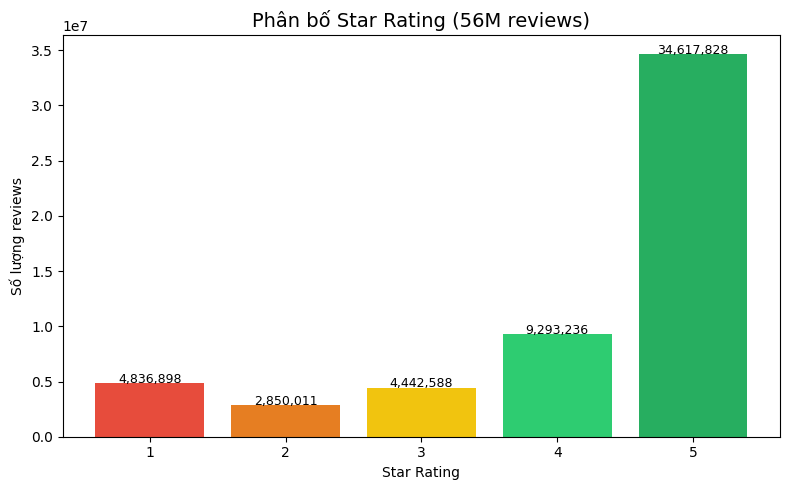

In [6]:
from pyspark.sql.functions import count, col, avg, countDistinct, sum as spark_sum

rating_dist = df.groupBy("star_rating") \
    .count().orderBy("star_rating").toPandas()

plt.figure(figsize=(8, 5))
bars = plt.bar(rating_dist["star_rating"], rating_dist["count"],
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.title("Phân bố Star Rating (56M reviews)", fontsize=14)
plt.xlabel("Star Rating")
plt.ylabel("Số lượng reviews")
for bar, val in zip(bars, rating_dist["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

total      = rating_dist["count"].sum()
positive   = rating_dist[rating_dist["star_rating"] >= 4]["count"].sum()
negative   = rating_dist[rating_dist["star_rating"] <= 2]["count"].sum()
five_star  = rating_dist[rating_dist["star_rating"] == 5]["count"].values[0]
one_star   = rating_dist[rating_dist["star_rating"] == 1]["count"].values[0]


Insight:
- Phân bố rating lệch mạnh: ~78.4% là positive (≥4 sao), 1 sao ít hơn ~7.2 lần so với 5 sao

Problem:
- Class imbalance → nếu làm sentiment classification, model dễ bias về class đa số (5 sao) → accuracy cao nhưng không phản ánh đúng

Hướng xử lý:
- Với Recommendation (ALS): không cần xử lý, vì dùng rating trực tiếp
- Với Sentiment:
    + Dùng class_weight
    + Hoặc undersample (giảm 5 sao) / oversample (tăng 1–2 sao)

6. USER BEHAVIOR

+-------+--------------------+------------------+
|summary|         customer_id|       num_reviews|
+-------+--------------------+------------------+
|  count|            18407629|          18407629|
|   mean|2.6938493697637595E7|3.0444203867863697|
| stddev|1.6087638494974336E7|  9.74646045075274|
|    min|             1000000|                 1|
|    max|             9999998|             18022|
+-------+--------------------+------------------+



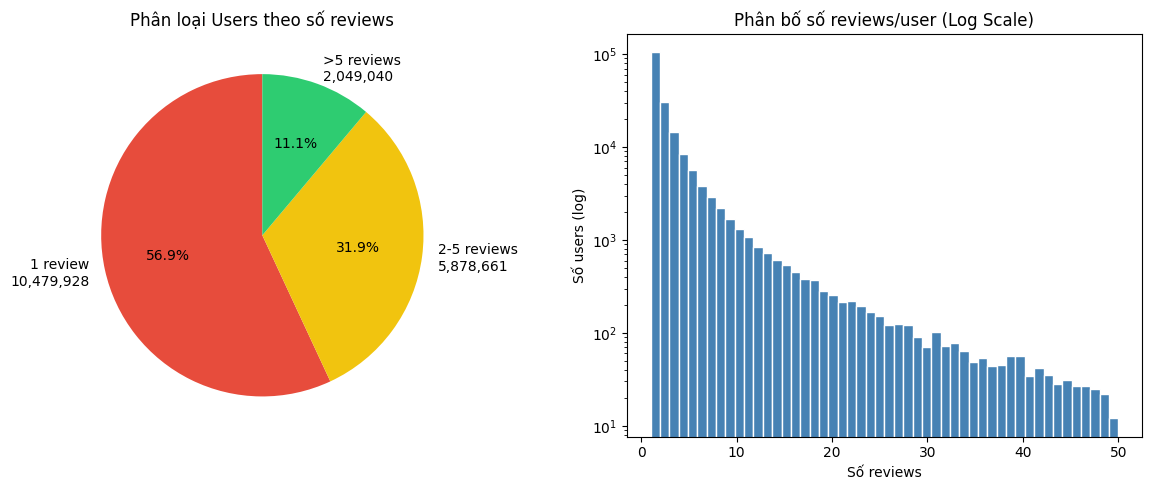

In [7]:
user_activity = df.groupBy("customer_id") \
    .count().withColumnRenamed("count", "num_reviews")

user_activity.describe().show()

stats = user_activity.select(
    spark_sum((col("num_reviews") == 1).cast("int")).alias("users_1_review"),
    spark_sum(col("num_reviews").between(2,5).cast("int")).alias("users_2to5"),
    spark_sum((col("num_reviews") > 5).cast("int")).alias("users_5plus"),
    count("*").alias("total_users")
).toPandas()

u1     = int(stats["users_1_review"][0])
u2_5   = int(stats["users_2to5"][0])
u5plus = int(stats["users_5plus"][0])
total_users = int(stats["total_users"][0])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie([u1, u2_5, u5plus],
        labels=[f'1 review\n{u1:,}', f'2-5 reviews\n{u2_5:,}', f'>5 reviews\n{u5plus:,}'],
        colors=['#e74c3c','#f1c40f','#2ecc71'],
        autopct='%1.1f%%', startangle=90)
plt.title("Phân loại Users theo số reviews")


user_sample = user_activity.filter(col("num_reviews") <= 50) \
    .sample(0.01).toPandas()
plt.subplot(1, 2, 2)
plt.hist(user_sample["num_reviews"], bins=50,
         color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title("Phân bố số reviews/user (Log Scale)")
plt.xlabel("Số reviews")
plt.ylabel("Số users (log)")
plt.tight_layout()
plt.show()


Insight:
- Hơn 1 nửa user chỉ review đúng 1 lần → dữ liệu rất ít tương tác, không đủ để hiểu họ thích gì

Problem:
- User mới / ít data → model không đoán được sở thích → gợi ý dễ sai

Hướng xử lý:
- Lọc bớt dữ liệu “yếu”:
- Chỉ giữ user có ≥ 5 review
- Chỉ giữ sản phẩm có ≥ 10 review
- → Giữ lại phần data “chất lượng hơn”, giúp model học tốt hơn (dù mất bớt dữ liệu)

7. ITEM ANALYSIS

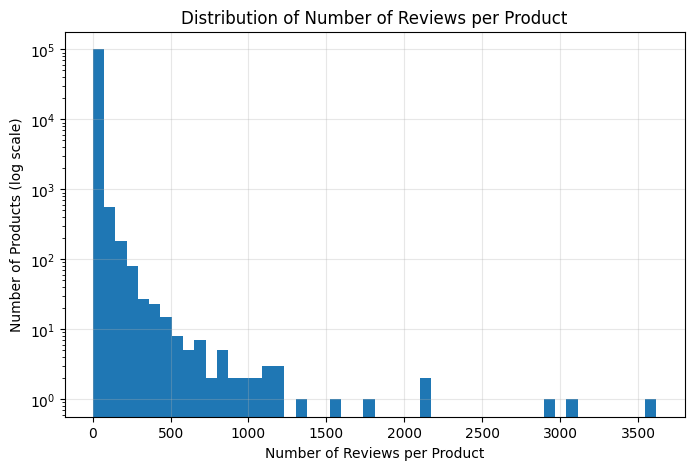

In [8]:
df_count = df.groupBy("product_id").agg(count("*").alias("count"))

sample = df_count.sample(fraction=0.01).toPandas()

plt.figure(figsize=(8, 5))
plt.hist(sample["count"], bins=50)
plt.yscale("log")

plt.title("Distribution of Number of Reviews per Product")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products (log scale)")

plt.grid(alpha=0.3)
plt.show()

Insight:
- Phân bố dạng long-tail: rất nhiều sản phẩm có ít review, chỉ vài sản phẩm có rất nhiều review

Problem:
- Cold Start (item): sản phẩm ít review → khó recommend
- Popularity bias: model thiên về sản phẩm nhiều review
- Rating không ổn định: item ít review dễ bị lệch

Hướng xử lý:
- Dùng log transform (log(1 + num_reviews)) để giảm chênh lệch
- Kết hợp Collaborative + Content-based (Hybrid)
- Ưu tiên review gần đây
- Có thể filter item ít review hoặc đặt ngưỡng tối thiểu

8. SPARSITY ANALYSIS

In [9]:
#BEFORE FILTER
n_users = df.select("customer_id").distinct().count()
n_items = df.select("product_id").distinct().count()
n_interactions = df.count()

sparsity = 1 - n_interactions / (n_users * n_items)

print(f"Sparsity: {sparsity:.4%}")

Sparsity: 100.0000%


Insight:
- Dữ liệu cực kỳ thưa (~100%), nhiều user/item có rất ít tương tác

Problem:
- Sparsity cao → model khó học, dễ nhiễu và tốn tài nguyên
- Nhiều user/item ít tương tác không đủ thông tin để học preference

Hướng xử lý:
- Filter user/item ít tương tác để giảm sparsity
- Giữ lại dữ liệu “chất lượng” → giúp ALS học ổn định và chính xác hơn

In [10]:
#FILTER DATA
# Filter user (User ≥ 5 reviews → đủ hiểu hành vi)
user_counts = df.groupBy("customer_id").count().filter(col("count") >= 5)
df_user_filtered = df.join(user_counts.select("customer_id"), on="customer_id")

# Filter item (Item ≥ 10 reviews → đủ đáng tin)
item_counts = df_user_filtered.groupBy("product_id").count().filter(col("count") >= 10)
df_filtered = df_user_filtered.join(item_counts.select("product_id"), on="product_id")

In [11]:
#AFTER FILTER
n_users_f  = df_filtered.select("customer_id").distinct().count()
n_items_f  = df_filtered.select("product_id").distinct().count()
n_inter_f  = df_filtered.count()

sparsity_f = 1 - n_inter_f / (n_users_f * n_items_f)

# PRINT TABLE
print(f"\n=== SPARSITY ANALYSIS ===")
print(f"{'':20} {'Before':>15} {'After':>15}")
print(f"{'Users':20} {n_users:>15,} {n_users_f:>15,}")
print(f"{'Items':20} {n_items:>15,} {n_items_f:>15,}")
print(f"{'Interactions':20} {n_interactions:>15,} {n_inter_f:>15,}")
print(f"{'Sparsity':20} {sparsity:>14.4%} {sparsity_f:>14.4%}")


=== SPARSITY ANALYSIS ===
                              Before           After
Users                     18,407,629       2,552,216
Items                     10,145,787         529,113
Interactions              56,040,561      19,668,879
Sparsity                  100.0000%       99.9985%


Sau khi filter data:
- Giảm size nhưng tăng data quality
- Trade-off: mất data nhưng model tốt hơn

9. Category Analysis

      product_category  num_reviews  num_products  num_users  avg_rating
                 Music      3002127        625209    1402055    4.436575
              Wireless      3002071        503781    2276249    3.891924
                 Shoes      3001522       1478938    2119682    4.240457
               Apparel      3000655       1452800    1983012    4.105290
                  Toys      2999942        522676    1813665    4.210711
            Automotive      2999693        696553    1705153    4.246607
           Electronics      2999536        183308    2102652    4.035648
                Sports      2999478        781892    1968581    4.229219
                Beauty      2999447        454547    1911997    4.186610
                 Books      2999293        699879    1661238    4.208948
Health & Personal Care      2998219        373958    2013134    4.161650
             Video DVD      2997958        250716    1432932    4.300733
                    PC      2997937        302780  

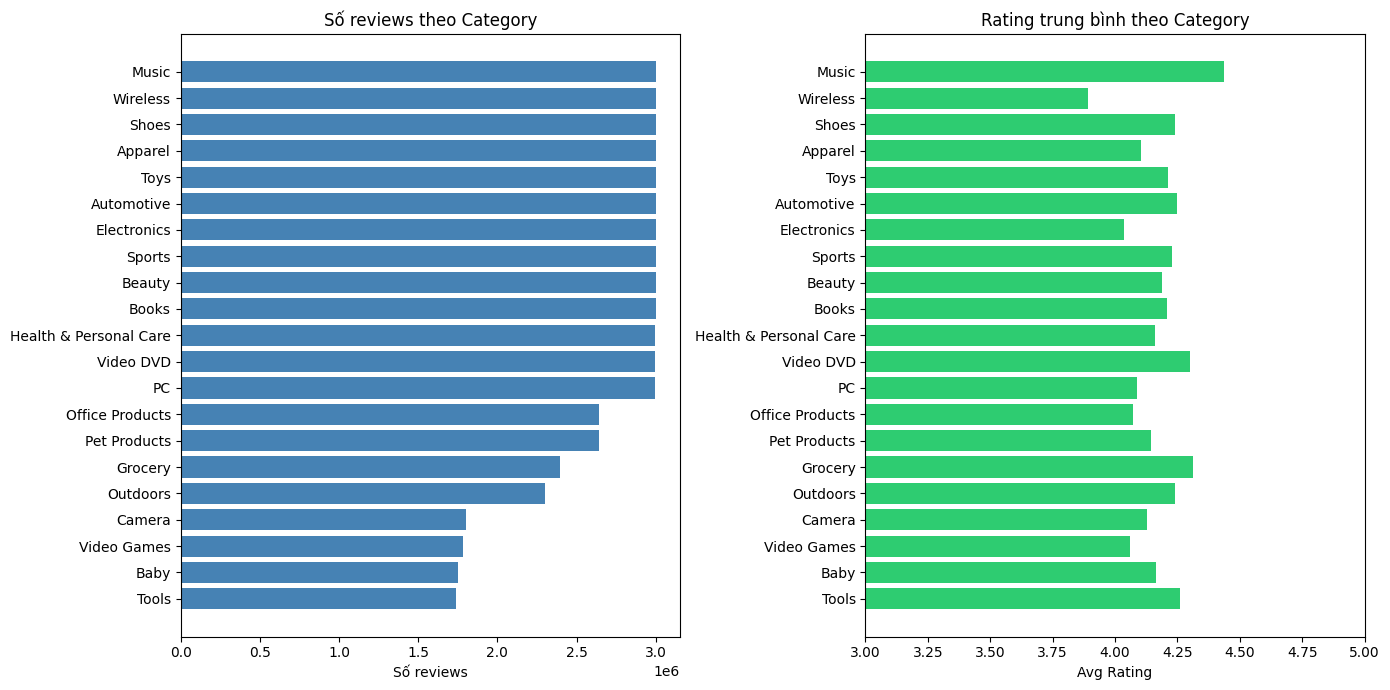

In [12]:
cat_pd = df.groupBy("product_category").agg(
    count("*").alias("num_reviews"),
    countDistinct("product_id").alias("num_products"),
    countDistinct("customer_id").alias("num_users"),
    avg("star_rating").alias("avg_rating")
).orderBy("num_reviews", ascending=False).toPandas()

cat_pd.show() if hasattr(cat_pd, 'show') else print(cat_pd.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(cat_pd["product_category"][::-1],
             cat_pd["num_reviews"][::-1], color='steelblue')
axes[0].set_title("Số reviews theo Category")
axes[0].set_xlabel("Số reviews")

axes[1].barh(cat_pd["product_category"][::-1],
             cat_pd["avg_rating"][::-1], color='#2ecc71')
axes[1].set_title("Rating trung bình theo Category")
axes[1].set_xlabel("Avg Rating")
axes[1].set_xlim(3, 5)
plt.tight_layout()
plt.show()

Insight:
- Dữ liệu giữa các category không đồng đều (Music/Wireless rất lớn, nhóm khác nhỏ hơn)
- Độ tin cậy rating khác nhau giữa các ngành (có ngành nhiều review/product, có ngành rất ít)
- Số lượng user theo từng category bị trùng lặp (1 user có thể mua nhiều ngành)

Problem:
- Imbalance → ngành lớn chi phối kết quả, gây bias
- Outlier (Wireless) → kéo lệch đánh giá chung
- Rating không đáng tin ở ngành ít review/product
- Sai lệch khi đếm user nếu cộng dồn theo category

Hướng xử lý:
- Nhóm category (high-volume vs niche) hoặc weighting khi tính toán
- Phân tích riêng Wireless (deep-dive) hoặc dùng median thay mean
- Tính thêm reviews_per_product, dùng Bayesian average để ổn định rating
- Dùng unique user_id để tránh đếm trùng, phân tích đúng hành vi user

10. Verified Purchase Analysis

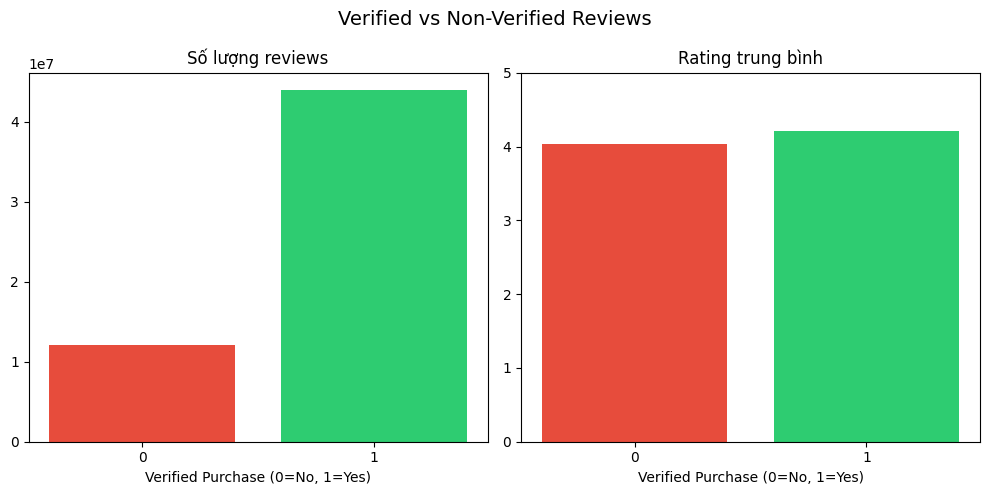

In [13]:
ver_pd = df.groupBy("verified_purchase").agg(
    count("*").alias("count"),
    avg("star_rating").alias("avg_rating")
).orderBy("verified_purchase").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(ver_pd["verified_purchase"].astype(str),
            ver_pd["count"], color=['#e74c3c','#2ecc71'])
axes[0].set_title("Số lượng reviews")
axes[0].set_xlabel("Verified Purchase (0=No, 1=Yes)")

axes[1].bar(ver_pd["verified_purchase"].astype(str),
            ver_pd["avg_rating"], color=['#e74c3c','#2ecc71'])
axes[1].set_title("Rating trung bình")
axes[1].set_xlabel("Verified Purchase (0=No, 1=Yes)")
axes[1].set_ylim(0, 5)
plt.suptitle("Verified vs Non-Verified Reviews", fontsize=14)
plt.tight_layout()
plt.show()


Insight:
- Review Verified nhiều gấp gần 4 lần và có rating cao hơn (~4.2 vs ~4.0)
- Người mua thật có xu hướng hài lòng và đánh giá tích cực hơn

Problem:
- Non-verified vẫn rất lớn → có thể gây nhiễu (review ảo, dìm hàng)
- Rating thấp hơn → có thể kéo giảm điểm trung bình sản phẩm
- Phụ thuộc nhiều vào nhóm Verified → nếu chất lượng giảm sẽ ảnh hưởng mạnh

Hướng xử lý:
- Ưu tiên Verified: đẩy lên top, khuyến khích review (voucher, UGC)
- Kiểm soát Non-verified: lọc nhiễu, detect spam/fake review
- Tăng verified reviews bằng cách nhắc user sau khi mua hàng

11. OUTLIER ANALYSIS
Outlier là những điểm dữ liệu có giá trị khác biệt lớn so với phần còn lại.

Trong dataset này:
- review quá dài → có thể là spam / bot
- review quá ngắn → có thể là noise

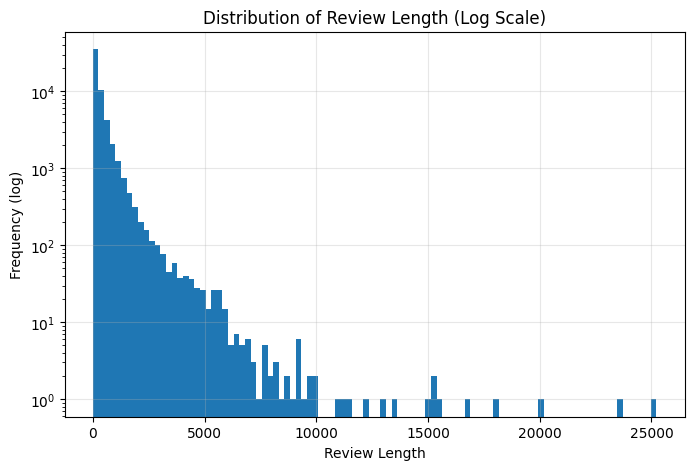

In [14]:
#Histogram (Log Scale)
rl_sample = df.select("review_length").sample(0.001).toPandas()

plt.figure(figsize=(8,5))
plt.hist(rl_sample["review_length"], bins=100)
plt.yscale("log")

plt.title("Distribution of Review Length (Log Scale)")
plt.xlabel("Review Length")
plt.ylabel("Frequency (log)")
plt.grid(alpha=0.3)
plt.show()

Insight:
- Phân bố lệch phải mạnh (long-tail): phần lớn review rất ngắn, tập trung dưới ~1000 ký tự
- Tồn tại một số ít review cực dài (10,000+ ký tự) tạo thành đuôi dài
- Chênh lệch rất lớn giữa review phổ biến và review hiếm → phân bố không cân đối

Problem:
- Review quá ngắn → thiếu semantic value, không giúp model học (noise)
- Review quá dài → có thể là spam/bot, làm tăng chi phí tính toán và gây nhiễu
- Phân bố lệch mạnh → mean không đại diện, dễ chọn threshold sai nếu không dùng percentile

Hướng xử lý:
- Loại bỏ review không có giá trị: review_length < 10
- Loại bỏ outlier bằng percentile: review_length > P99
- Chọn max_length cho NLP (~500–1000) để giữ phần lớn dữ liệu nhưng tối ưu hiệu năng

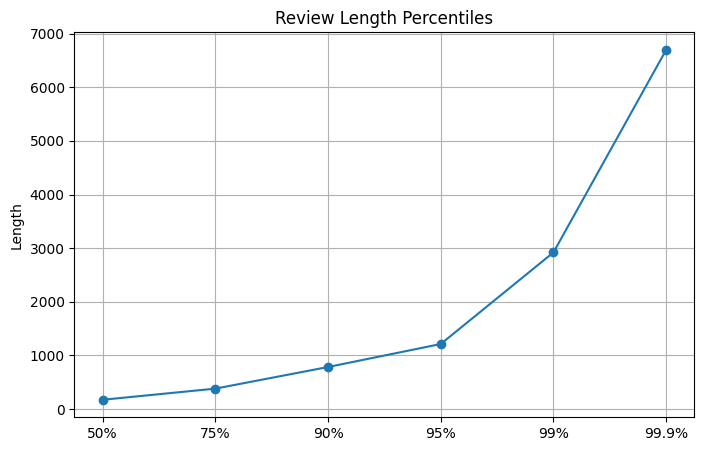

50%: 172
75%: 380
90%: 783
95%: 1212
99%: 2921
99.9%: 6699


In [15]:
#Percentile Analysis
import pyspark.sql.functions as F
percentiles = df.select(
    F.expr("percentile_approx(review_length, array(0.5, 0.75, 0.9, 0.95, 0.99, 0.999)) as p")
).collect()[0]["p"]

labels = ["50%", "75%", "90%", "95%", "99%", "99.9%"]

plt.figure(figsize=(8,5))
plt.plot(labels, percentiles, marker='o')
plt.title("Review Length Percentiles")
plt.ylabel("Length")
plt.grid()
plt.show()

for l, v in zip(labels, percentiles):
    print(f"{l}: {v}")

Insight:
- 50% review chỉ ~172 ký tự → đa số rất ngắn
- 95% review < ~1200 → phần lớn dữ liệu nằm trong khoảng nhỏ
- Từ 99% (~2900) → 99.9% (~6700) tăng rất mạnh → đuôi dài rõ rệt (outlier)

Problem:
- Phần lớn dữ liệu tập trung ở vùng nhỏ nhưng bị kéo lệch bởi một số ít review rất dài
- Nếu không xử lý:
    + Model bị ảnh hưởng bởi outlier
    + Tăng chi phí xử lý (đặc biệt với NLP)
- Mean không còn ý nghĩa → dễ chọn threshold sai

Hướng xử lý:
- Dùng percentile để filter thay vì mean
- Loại bỏ outlier: review_length > P99 (~2900)
- Loại bỏ noise: review_length < 10
- Chọn max_length ~500–1000 (cover >90–95% data, tối ưu hiệu năng)

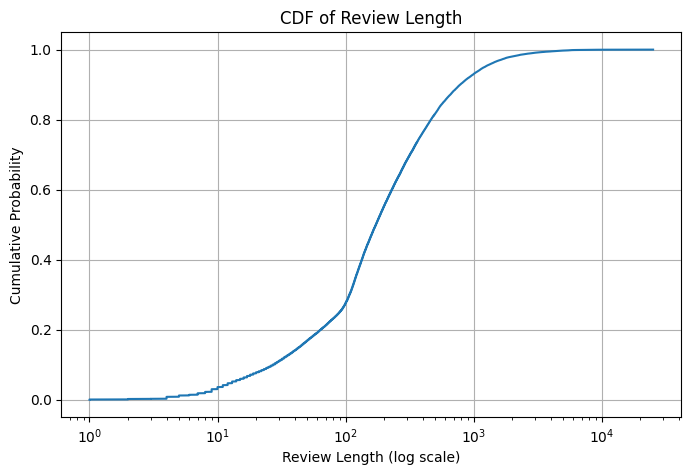

In [16]:
#CDF Plot
import numpy as np

data = rl_sample["review_length"].sort_values()
cdf = np.arange(len(data)) / float(len(data))

plt.figure(figsize=(8,5))
plt.plot(data, cdf)
plt.xscale("log")

plt.title("CDF of Review Length")
plt.xlabel("Review Length (log scale)")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()

Insight:
- Đường CDF tăng nhanh ở vùng 100 → 1000 ký tự → phần lớn review tập trung trong khoảng này
- 90–95% dữ liệu nằm dưới ~1000–1200
- Phần đuôi sau ~2000 tăng rất chậm → rất ít review dài (outlier)

Problem:
- Data tập trung mạnh ở vùng ngắn → phần đuôi dài không đại diện
- Nếu giữ toàn bộ:
    + Outlier làm nhiễu model
    + Tăng chi phí xử lý (NLP)
    + Khó chọn threshold nếu không nhìn CDF

Hướng xử lý:
- Dùng CDF để chọn ngưỡng hợp lý
- Giữ phần “mass” chính: max_length ~500–1000 (cover ~90–95%)
- Loại bỏ đuôi: review_length > P99
- Loại bỏ noise: review_length < 10

OUTLIER CLEANING

In [17]:
#Lấy threshold từ data (P1, P99)
q1, q99 = df.select(
    F.percentile_approx("review_length", 0.01),
    F.percentile_approx("review_length", 0.99)
).first()

print(f"P1: {q1}, P99: {q99}")

P1: 5, P99: 2921


In [18]:
# Filter outlier + noise
df_clean = (
    df_filtered
    .filter(col("review_length") >= 10)  # remove noise (quá ngắn)
    .filter(col("review_length") <= q99)  # remove outlier (đuôi dài)
)

In [19]:
# SAVE CLEAN DATA
df_clean.write.mode("overwrite").parquet(
    "/kaggle/working/amazon_reviews_cleaned_v2"
)

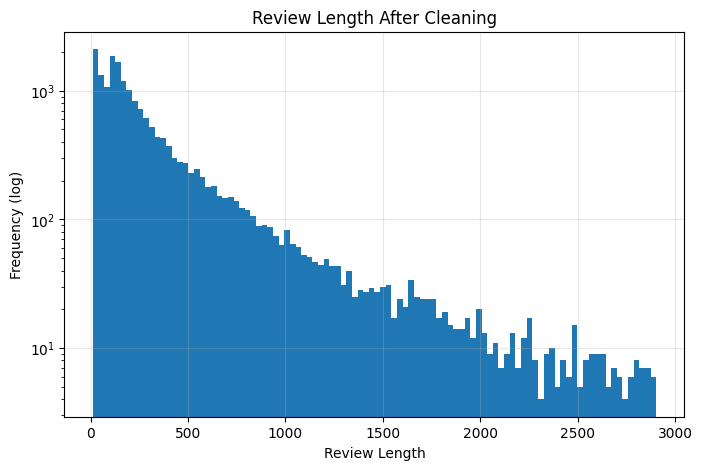

In [20]:
#VISUALIZE AFTER CLEAN
rl_clean = df_clean.select("review_length").sample(0.001).toPandas()

plt.figure(figsize=(8,5))
plt.hist(rl_clean["review_length"], bins=100)
plt.yscale("log")

plt.title("Review Length After Cleaning")
plt.xlabel("Review Length")
plt.ylabel("Frequency (log)")
plt.grid(alpha=0.3)
plt.show()

Sau khi loại bỏ các review quá ngắn (<10) và các outlier vượt quá P99 (~2900), dataset vẫn giữ lại khoảng ~99% dữ liệu quan trọng, trong đó phần lớn review tập trung trong khoảng 100–1200 ký tự, giúp phân bố trở nên ổn định hơn, giảm nhiễu từ các giá trị cực đoan và đảm bảo chất lượng dữ liệu đủ tốt để huấn luyện các mô hình recommendation và NLP một cách hiệu quả.